### Loading Data ###


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("credit_risk_dataset.csv")

### Looking at the Data ###



In [3]:
df.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### Auditing the Data ###

In [6]:
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(165)

In [8]:
df["loan_status"].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [9]:
df["loan_status"].value_counts(normalize=True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

### EDA ###

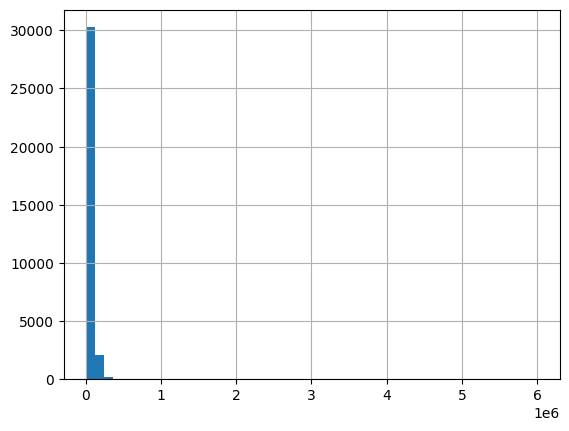

In [10]:
import matplotlib.pyplot as plt

df["person_income"].hist(bins=50)
plt.show()

<Axes: >

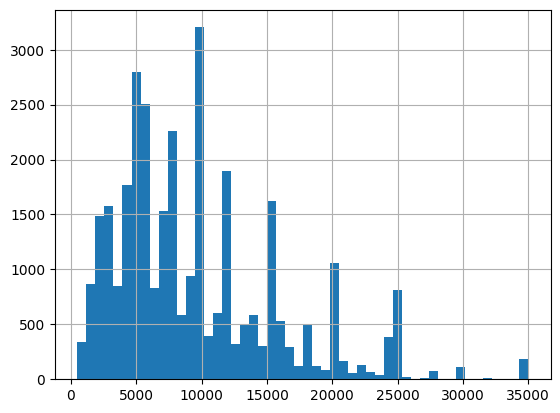

In [11]:
df["loan_amnt"].hist(bins=50)

<Axes: >

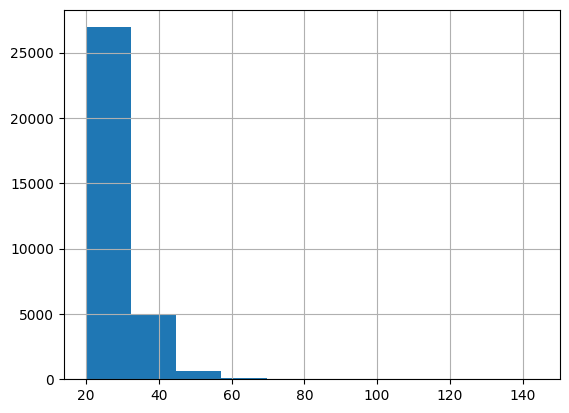

In [12]:
df["person_age"].hist()

In [13]:
df.groupby("loan_status")["person_income"].mean()

loan_status
0    70804.361559
1    49125.652223
Name: person_income, dtype: float64

In [14]:
df.groupby("loan_status")["loan_amnt"].mean()

loan_status
0     9237.464178
1    10850.502954
Name: loan_amnt, dtype: float64

### Handling Missing Values ###

In [15]:
df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)

C:\Users\pthor\AppData\Local\Temp\ipykernel_11208\58522341.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)


In [16]:
df = df[df["person_age"] < 100]

### Feature Engineering ###

In [17]:
df["loan_to_income_ratio"] = (
    df["loan_amnt"] /
    df["person_income"]
)

In [18]:
df["income_credit_hist_ratio"] = (
    df["person_income"] /
    (df["cb_person_cred_hist_length"] + 1)
)

In [19]:
df.select_dtypes(include="object").columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [20]:
df = pd.get_dummies(
    df,
    drop_first=True
)

### Train - Test Splits ###

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Baseline Logistic Regression ###

In [24]:
from sklearn.preprocessing import StandardScaler

In [31]:
X_train.isnull().sum().sort_values(ascending=False).head(20)

loan_int_rate                  2517
person_age                        0
person_emp_length                 0
person_income                     0
loan_amnt                         0
loan_percent_income               0
cb_person_cred_hist_length        0
loan_to_income_ratio              0
income_credit_hist_ratio          0
person_home_ownership_OTHER       0
person_home_ownership_OWN         0
person_home_ownership_RENT        0
loan_intent_EDUCATION             0
loan_intent_HOMEIMPROVEMENT       0
loan_intent_MEDICAL               0
loan_intent_PERSONAL              0
loan_intent_VENTURE               0
loan_grade_B                      0
loan_grade_C                      0
loan_grade_D                      0
dtype: int64

In [32]:
# Fill missing values using training-set medians
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [35]:
preds = lr.predict(X_test_scaled)

### Evaluating Metrics ###

In [36]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, preds)

array([[4847,  247],
       [ 600,  822]])

In [38]:
from sklearn.metrics import roc_auc_score

probs = lr.predict_proba(X_test_scaled)[:,1]

roc_auc_score(y_test, probs)

0.8740201787271311

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5094
           1       0.77      0.58      0.66      1422

    accuracy                           0.87      6516
   macro avg       0.83      0.76      0.79      6516
weighted avg       0.86      0.87      0.86      6516



### Cross Validation ###

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

In [42]:
scores.mean()

np.float64(0.8765090919178761)

### Random Forest ###

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
preds1 = rf.predict(X_test)

### Evaluating RF ###

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test,preds1))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5094
           1       0.96      0.72      0.82      1422

    accuracy                           0.93      6516
   macro avg       0.94      0.85      0.89      6516
weighted avg       0.93      0.93      0.93      6516



In [53]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, preds1)

array([[5052,   42],
       [ 403, 1019]])

In [56]:
from sklearn.metrics import roc_auc_score

probs1 = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, probs1)

0.9308292428642506

### XGBoost ###

In [57]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state = 42
)

In [58]:
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [59]:
preds2 = xgb.predict(X_test)

### Evaluating XGboost ###

In [60]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, preds2)

array([[5037,   57],
       [ 373, 1049]])

In [61]:
from sklearn.metrics import classification_report

classification_report(y_test, preds2)

'              precision    recall  f1-score   support\n\n           0       0.93      0.99      0.96      5094\n           1       0.95      0.74      0.83      1422\n\n    accuracy                           0.93      6516\n   macro avg       0.94      0.86      0.89      6516\nweighted avg       0.93      0.93      0.93      6516\n'

In [62]:
from sklearn.metrics import roc_auc_score

probs2 = xgb.predict_proba(X_test_scaled)[:,1]

roc_auc_score(y_test, probs2)

0.7594109779741425

### Feature Importance ###

In [63]:
rf.feature_importances_

array([0.03895191, 0.1080805 , 0.04982493, 0.05596037, 0.1014216 ,
       0.13148562, 0.02753993, 0.14909597, 0.05957142, 0.00097165,
       0.01688745, 0.07982893, 0.01361599, 0.01374134, 0.01444833,
       0.01118084, 0.01055101, 0.00457498, 0.01474704, 0.06206306,
       0.01510512, 0.0058858 , 0.0022302 , 0.01223599])

In [64]:
xgb.feature_importances_

array([0.01163509, 0.0381279 , 0.01897622, 0.00926535, 0.05343297,
       0.02220823, 0.00760199, 0.10818942, 0.00852478, 0.02140202,
       0.06391503, 0.16935825, 0.0263171 , 0.048549  , 0.06000528,
       0.03380472, 0.05814206, 0.01736164, 0.07705601, 0.07326823,
       0.02509634, 0.01696881, 0.02158214, 0.00921149], dtype=float32)